# 20 May 2026 — Transformation and Analysis Goal

## Focus
I will focus on the `Culture` and `Country` columns of the MET 
dataset to analyse geographic and cultural distribution of objects.

## Transformation
I will clean the Culture column by filling empty values with 
"Unknown", then count how many objects come from each culture.

## Analysis and Visualisation Goal
Count objects per culture (top 15) and produce a horizontal 
bar chart. This directly answers my research question about 
which cultures are most represented in the MET collection.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the dataset — do not change the original file
df = pd.read_csv('../data/asian_islamic_neareastern_met.csv', 
                 low_memory=False)
print(f"Loaded {len(df)} rows")
print(f"Sample of Culture column:\n{df['Culture'].head(10)}")

Loaded 58796 rows
Sample of Culture column:
0    Japan
1    China
2    China
3    China
4    China
5    China
6    China
7    China
8    China
9    China
Name: Culture, dtype: object


## Step 1: Cleaning the Culture column
Fill missing values with "Unknown" to avoid losing data in counts.
This is a decision that must be documented — "Unknown" does not 
mean the object has no culture, just that it is not recorded.

In [18]:
# Fill missing Culture values with "Unknown"
df_clean = df.copy()  # never change the original
df_clean['Culture'] = df_clean['Culture'].fillna('Unknown')

print(f"Missing values in Culture before: {df['Culture'].isna().sum()}")
print(f"Missing values in Culture after: {df_clean['Culture'].isna().sum()}")
print(f"\nSample after cleaning:\n{df_clean['Culture'].head(10)}")

Missing values in Culture before: 16679
Missing values in Culture after: 0

Sample after cleaning:
0    Japan
1    China
2    China
3    China
4    China
5    China
6    China
7    China
8    China
9    China
Name: Culture, dtype: object


## Step 2: Analysis — Count objects per culture (top 15)

In [21]:
# Count objects per culture, get top 15
culture_counts = df_clean['Culture'].value_counts().head(15)
print("Top 15 cultures by object count:")
print(culture_counts)

# Save counts to data folder
os.makedirs('../data', exist_ok=True)
culture_counts.to_csv('../data/culture_counts.csv', header=True)
print("\nSaved to data/culture_counts.csv")

Top 15 cultures by object count:
Culture
Japan                                      16937
Unknown                                    16682
China                                      13502
Iran                                        1066
Sasanian                                     916
Indonesia (Java)                             697
Korea                                        581
Assyrian                                     480
India                                        453
Thailand                                     382
Babylonian                                   347
Tibet                                        279
Bactria-Margiana Archaeological Complex      222
Indonesia (Central Java)                     208
India (Gujarat)                              204
Name: count, dtype: int64

Saved to data/culture_counts.csv


## Step 3: Visualisation — Horizontal bar chart of top 15 cultures

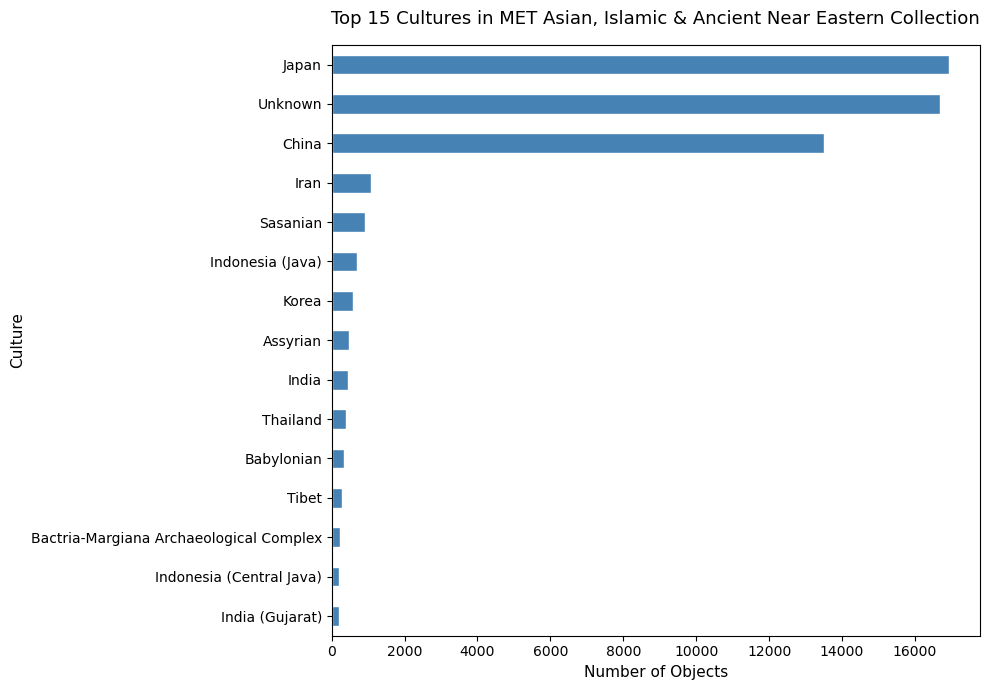

Chart saved to data/culture_distribution.png


In [24]:
# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))

culture_counts.sort_values().plot(
    kind='barh', 
    ax=ax, 
    color='steelblue',
    edgecolor='white'
)

ax.set_title('Top 15 Cultures in MET Asian, Islamic & Ancient Near Eastern Collection', 
             fontsize=13, pad=15)
ax.set_xlabel('Number of Objects', fontsize=11)
ax.set_ylabel('Culture', fontsize=11)

plt.tight_layout()

# Save the plot
os.makedirs('../data', exist_ok=True)
plt.savefig('../data/culture_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/culture_distribution.png")

## Interpretation

**What pattern do I see in the plot?**
Japanese culture dominates the collection with over 16,000 objects, 
followed by Chinese culture with around 13,000. Indian and Iranian 
cultures appear much further down the ranking with under 1,500 
objects each. The distribution is heavily skewed toward East Asian 
cultures.

**How does this relate to my research question?**
This directly answers my question about cultural distribution — 
the MET collection is far from evenly distributed. East Asian 
(Japanese and Chinese) objects vastly outnumber objects from South 
Asian and Middle Eastern cultures, even though all three departments 
are included.

**One limitation of this result:**
This result reflects the MET's collecting history, not the actual 
distribution of cultural production globally. Japanese and Chinese 
collections were actively acquired in the 19th and early 20th 
centuries, which skews the numbers significantly. Additionally, 
28% of objects have no Culture recorded at all, which means the 
true distribution may look different.

## Entities that could be enhanced with Wikidata

Based on my dataset columns, the following entities could be 
linked to Wikidata for enrichment:

**Persons:**
- `Artist Display Name` — many named artists exist in Wikidata
  (e.g. Katsushika Hokusai, Utagawa Hiroshige)

**Places:**
- `Country` — all countries exist in Wikidata with coordinates,
  population, region data (e.g. Japan, Iran, India)
- `City` — cities could be linked to get coordinates for mapping

**Organisations:**
- `Credit Line` — mentions donor institutions and museums that
  exist in Wikidata (e.g. The Metropolitan Museum of Art itself)

**Works:**
- `Title` — some well-known artworks may exist in Wikidata
  with additional provenance information

**Most useful for my research question:**
Linking `Country` to Wikidata would allow me to add geographic 
coordinates and map the distribution of objects spatially, which 
would greatly strengthen the analysis.

## 6. Culture vs Period Analysis - Heatmap

Understanding the relationship between cultures and historical periods in the dataset.

This heatmap shows the concentration of objects from top cultures across top historical periods. 
It helps identify:
- Which cultures are well-represented in which periods
- Geographic and temporal distribution patterns
- Potential collecting biases by culture and time period

/var/folders/5b/rvy8kknj2fv8v6fd5lzkpc200000gn/T/ipykernel_3453/3373698180.py:6: DtypeWarning: Columns (28,29,30,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/nandinikapoor/My-first-Github-project/data/asian_islamic_neareastern_met.csv')


✓ Saved: culture_period_heatmap.png


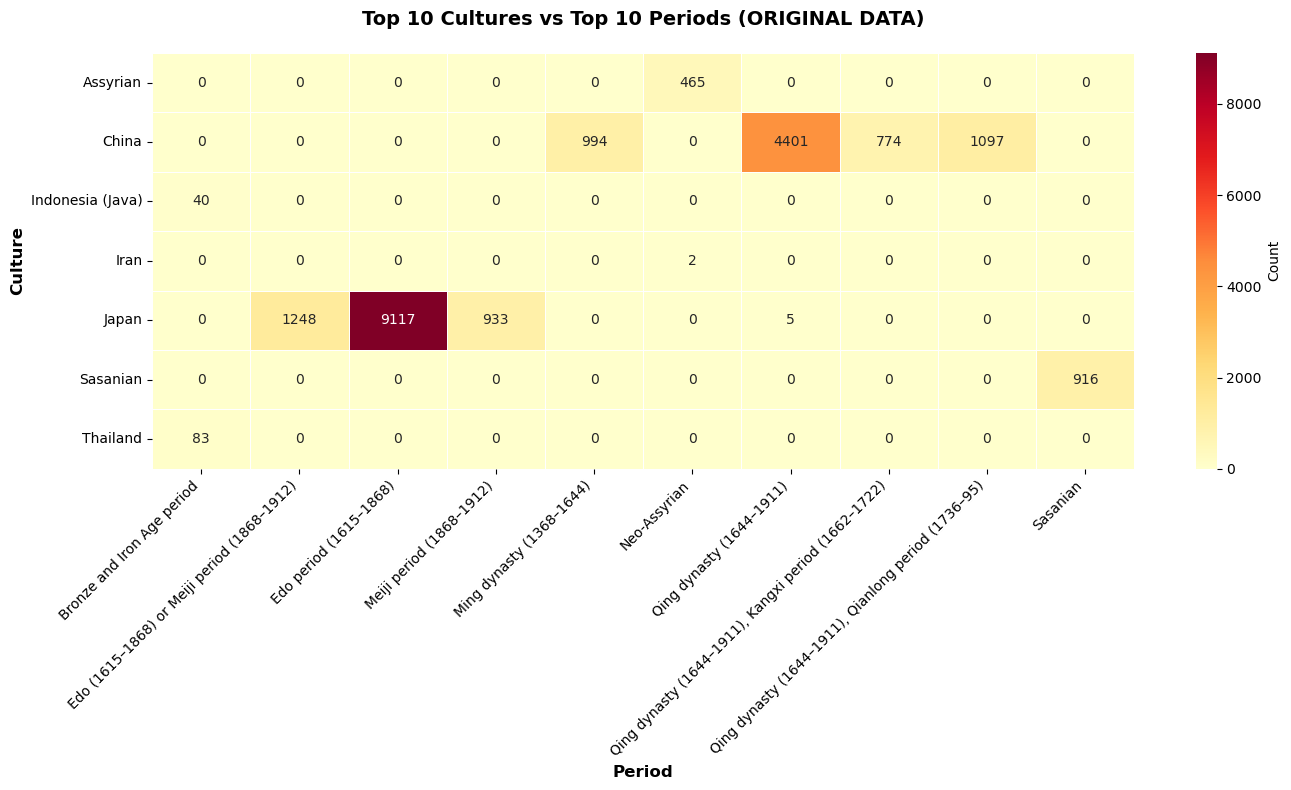

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load original CSV
df = pd.read_csv('/Users/nandinikapoor/My-first-Github-project/data/asian_islamic_neareastern_met.csv')

# Get top 10 cultures and top 10 periods
top_cultures = df['Culture'].value_counts().head(10).index
top_periods = df['Period'].value_counts().head(10).index

# Create crosstab
crosstab = pd.crosstab(
    df[df['Culture'].isin(top_cultures)]['Culture'],
    df[df['Period'].isin(top_periods)]['Period']
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Count'}, linewidths=0.5)
ax.set_title('Top 10 Cultures vs Top 10 Periods (ORIGINAL DATA)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Culture', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/Users/nandinikapoor/My-first-Github-project/data/culture_period_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: culture_period_heatmap.png")
plt.show()

### Interpretation: Culture-Period Patterns

#### Key Findings:

**1. Strong Japan-Edo Period Concentration**
- Japan dominates the Edo period (1615-1868) with 9,117 objects
- This represents the single largest culture-period combination in the dataset
- Suggests the museum has exceptional strength in Japanese art from this era

**2. China's Multi-Period Presence**
- China appears across multiple periods: Ming Dynasty (994), Qing Dynasty (4,401), and later periods
- More dispersed than Japan's concentrated Edo focus
- Reflects longer time span and broader geographic/cultural evolution

**3. Specialized vs. Distributed Collections**
- **Specialized cultures**: Assyrian (only Neo-Assyrian: 465), Thailand (only early period: 83), Indonesia (only Bronze Age: 40)
- **Distributed cultures**: China, Japan spread across multiple periods
- Indicates museum acquired objects opportunistically rather than systematically across all periods

**4. Museum Collecting Bias**
- **Strong East Asian bias**: Japan + China = majority of objects
- **Weak Islamic/Middle Eastern coverage**: Iran only 2 objects, minimal Sassanian presence
- **Ancient Near East underrepresented**: Assyrian limited to one period
- Original collection scope was geographically limited despite department names

**5. Data Quality Implication**
- **Missing period data**: Many cultures have NULL periods (not shown in heatmap)
- **Uneven documentation**: Some culture-period combinations lack any representation
- **Research implications**: Future analysis should account for these biases

#### What This Means:

This heatmap **visually demonstrates the collecting history of the museum**. Rather than a comprehensive representation of Asian, Islamic, and Ancient Near Eastern art, the collection reflects:
- Market availability of objects in acquisition period
- Museum's specific curatorial interests
- Budget constraints and acquisition opportunities
- Scholarly priorities at time of collection

